
0: 384x640 1 person, 55.4ms
Speed: 3.5ms preprocess, 55.4ms inference, 2.1ms postprocess per image at shape (1, 3, 384, 640)


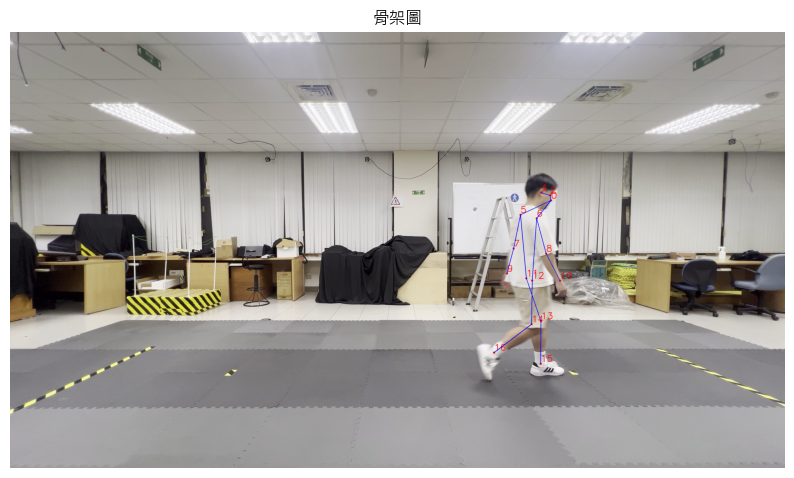

In [16]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

# YOLO 模型載入
model = YOLO('D:\\pythonProject\\IC Lab\\Gait_analysis\\pyskl\\tools\\data\\yolo11x-pose.pt')
model.classes = [0]  # 假設只檢測人，請根據需求修改類別索引

# 定義骨架連接規則
inward = [
    (15, 13), (13, 11), (16, 14), (14, 12), (11, 5), (12, 6),
    (9, 7), (7, 5), (10, 8), (8, 6), (5, 0), (6, 0),
    (1, 0), (3, 1), (2, 0), (4, 2)
]

def draw_keypoints_and_skeleton(frame, keypoints, connections):
    """
    在影像上繪製關節點和骨架。
    """
    keypoints = keypoints[0]  # 去掉第一維，取得 (17, 3) 的陣列
    keypoints_xy = keypoints[:, :2]  # 只提取 x, y 座標

    # 繪製關節點
    for i, (x, y) in enumerate(keypoints_xy):
        if x > 0 and y > 0:  # 只繪製有效點
            cv2.circle(frame, (int(x), int(y)), 5, (0, 0, 255), -1)  # 紅點
            cv2.putText(frame, str(i), (int(x), int(y)-10), cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 0, 255), 2)

    # 繪製骨架
    for connection in connections:
        pt1, pt2 = connection
        if all(keypoints_xy[pt1]) and all(keypoints_xy[pt2]):  # 確保連接的點有效
            cv2.line(frame, tuple(map(int, keypoints_xy[pt1])), tuple(map(int, keypoints_xy[pt2])), (255, 0, 0), 2)  # 藍線

    return frame

def extract_and_process_frame(video_path, frame_idx=0):
    cap = cv2.VideoCapture(video_path)

    # 跳到指定的 frame
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    ret, frame = cap.read()

    if not ret:
        print(f"無法讀取第 {frame_idx} 幀。")
        return

    # YOLO 推論
    results = model(frame)
    keypoints = results[0].keypoints.data.cpu().numpy()

    # 假設 keypoints 是 17 個點的(x, y)，這裡需要更改為你的 YOLO 模型提供的格式
    
    keypoints = keypoints.astype(int)  # 轉為整數像素座標

    # 標記關節點
    frame_with_keypoints = draw_keypoints_and_skeleton(frame.copy(), keypoints, inward)

    # 顯示骨架圖
    plt.figure(figsize=(10, 10))
    plt.imshow(cv2.cvtColor(frame_with_keypoints, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title("骨架圖")
    plt.show()

    cap.release()
    return keypoints, frame

# 執行程式
video_path = r"D:\pythonProject\IC Lab\Gait_analysis\pyskl\tools\data\drunk\1029\40\sagittal\normal\40_sagittal_normal_01.MOV"
keypoints, frame = extract_and_process_frame(video_path, frame_idx=100)


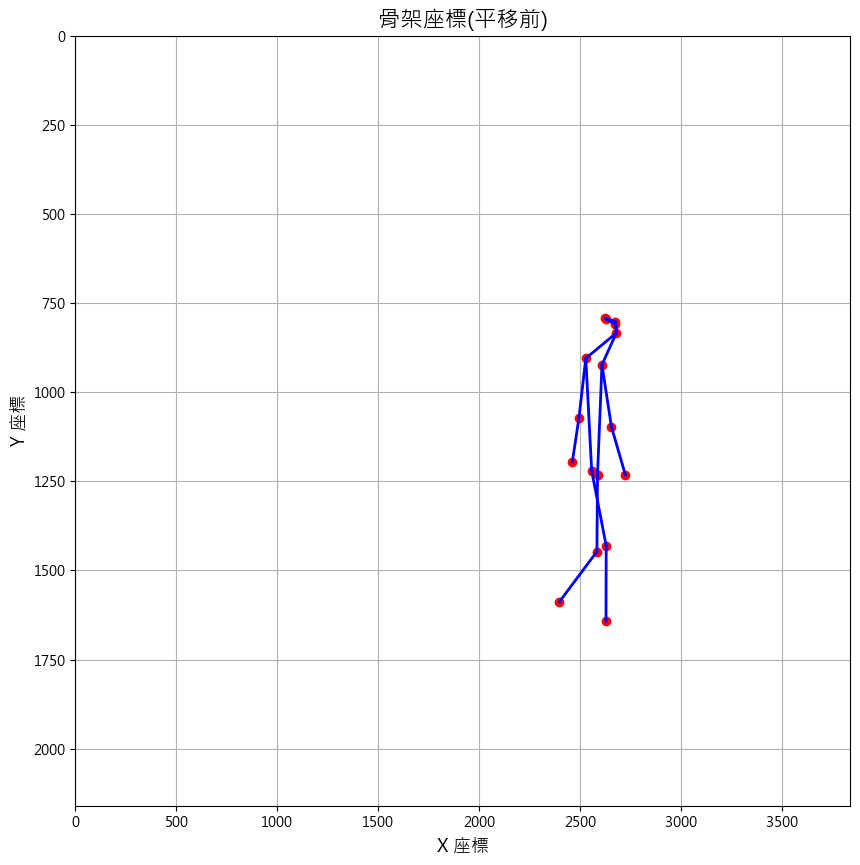

In [17]:
import matplotlib.pyplot as plt
from matplotlib import rcParams

# 設定支持中文的字體
rcParams['font.sans-serif'] = ['Microsoft JhengHei']  # 使用微軟正黑體（適用於 Windows）
rcParams['axes.unicode_minus'] = False  # 確保負號正常顯示

inward = [
    (15, 13), (13, 11), (16, 14), (14, 12), (11, 5), (12, 6),
    (9, 7), (7, 5), (10, 8), (8, 6), (5, 0), (6, 0),
    (1, 0), (3, 1), (2, 0), (4, 2)
]
def draw_keypoints_and_skeleton_with_axes(keypoints, connections, xlim=(-500, 500), ylim=(-500, 500), ax=None, title='骨架座標(平移前)'):
    """
    在空白畫布上繪製關節點和骨架，並顯示座標軸。
    """
    keypoints = keypoints[0]  # 去掉第一維，取得 (17, 3) 的陣列
    keypoints_xy = keypoints[:, :2]  # 只提取 x, y 座標

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 10))

    # 設置畫布大小（與 frame_size 相同）
    ax.set_xlim(xlim[0], xlim[1])
    ax.set_ylim(ylim[1], ylim[0])  # 注意 Matplotlib 的 y 軸是向下為負，需要反轉

    # 繪製關節點
    for i, (x, y) in enumerate(keypoints_xy):
        ax.plot(x, y, 'ro')  # 紅點
        # ax.text(x, y - 10, str(i), color="green", fontsize=10, ha='center')  # 標記 index

    # 繪製骨架
    for connection in connections:
        pt1, pt2 = connection
        if all(keypoints_xy[pt1]) and all(keypoints_xy[pt2]):  # 確保連接的點有效
            x_coords = [keypoints_xy[pt1][0], keypoints_xy[pt2][0]]
            y_coords = [keypoints_xy[pt1][1], keypoints_xy[pt2][1]]
            ax.plot(x_coords, y_coords, 'b-', linewidth=2)  # 藍線

    # 添加座標軸標籤，並設定字體大小為 13
    ax.set_xlabel("X 座標", fontsize=13)
    ax.set_ylabel("Y 座標", fontsize=13)

    # 添加標題
    ax.set_title(title, fontsize=16)
    ax.grid(True)
    # 顯示骨架圖

    
    if ax is None:
        plt.title("骨架座標(平移前)")
        plt.grid(True)
        plt.show()
    # 不在函數中使用 plt.show()，這樣可以讓圖像被保存而不顯示

    # 無需返回 ax 和 fig，因為它們已經在外部被修改

# def draw_keypoints_and_skeleton_with_axes(keypoints, connections, frame_size, ax=None, fig=None):
#     """
#     在空白畫布上繪製關節點和骨架，並顯示座標軸。
#     """
#     keypoints = keypoints[0]  # 去掉第一維，取得 (17, 3) 的陣列
#     keypoints_xy = keypoints[:, :2]  # 只提取 x, y 座標

#     if ax is None:
#         fig, ax = plt.subplots(figsize=(10, 10))

#     # 設置畫布大小（與 frame_size 相同）
#     ax.set_xlim(0, frame_size[0])
#     ax.set_ylim(frame_size[1], 0)  # 注意 Matplotlib 的 y 軸是向下為負，需要反轉

#     # 繪製關節點
#     for i, (x, y) in enumerate(keypoints_xy):
#         ax.plot(x, y, 'ro')  # 紅點
#             # ax.text(x, y - 10, str(i), color="green", fontsize=10, ha='center')  # 標記 index

#     # 繪製骨架
#     for connection in connections:
#         pt1, pt2 = connection
#         if all(keypoints_xy[pt1]) and all(keypoints_xy[pt2]):  # 確保連接的點有效
#             x_coords = [keypoints_xy[pt1][0], keypoints_xy[pt2][0]]
#             y_coords = [keypoints_xy[pt1][1], keypoints_xy[pt2][1]]
#             ax.plot(x_coords, y_coords, 'b-', linewidth=2)  # 藍線

#     # 添加座標軸標籤，並設定字體大小為 13
#     ax.set_xlabel("X 座標", fontsize=13)
#     ax.set_ylabel("Y 座標", fontsize=13)

#     # 顯示骨架圖
#     plt.title("骨架座標(平移前)")
#     plt.grid(True)
#     plt.show()

#     return ax, fig

# 測試繪製在空白畫布上並添加座標軸
keypoints[0][1] = np.array([2676, 803, 0])
keypoints[0][3] = np.array([2625, 792, 0])

# 假設 frame 的大小是 (1920, 1080)
draw_keypoints_and_skeleton_with_axes(keypoints, inward, xlim=(0,3840), ylim=(0, 2160))



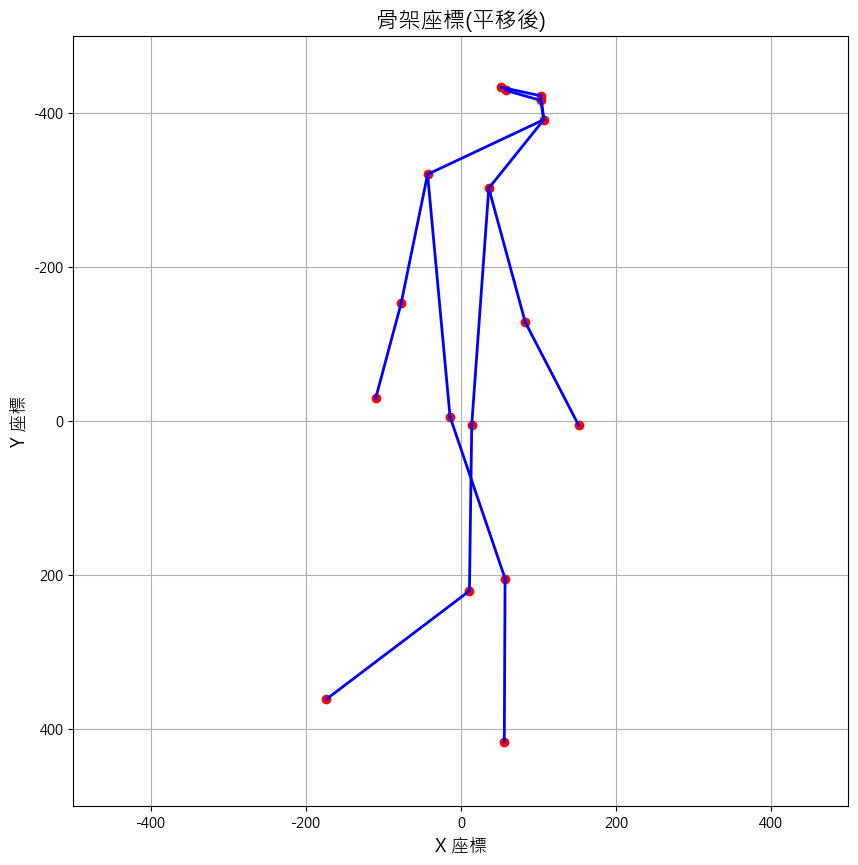

In [18]:
def translate_keypoints_to_origin(keypoints, left_hip_idx=11, right_hip_idx=12):
    """
    將 keypoints 平移，使髖關節中心位於 (0, 0)。
    
    Args:
        keypoints (np.ndarray): 原始關節點數據，形狀為 (1, 17, 3)。
        left_hip_idx (int): 左髖關節的索引，默認為 11。
        right_hip_idx (int): 右髖關節的索引，默認為 12。
    
    Returns:
        np.ndarray: 平移後的 keypoints。
    """
    keypoints = keypoints[0]  # 移除 batch 維度，取得 (17, 3)
    keypoints_xy = keypoints[:, :2]  # 提取 x, y 座標

    # 計算髖關節中心
    left_hip = keypoints_xy[left_hip_idx]
    right_hip = keypoints_xy[right_hip_idx]
    hip_center = (left_hip + right_hip) / 2

    # 平移 keypoints
    translated_keypoints = keypoints_xy - hip_center

    # 打包回原始格式
    keypoints[:, :2] = translated_keypoints  # 更新平移後的座標
    return keypoints[np.newaxis, :]  # 恢復到 (1, 17, 3)

keypoints = translate_keypoints_to_origin(keypoints)

# 測試數據，平移到原點後繪製
draw_keypoints_and_skeleton_with_axes(keypoints, inward, xlim=(-500, 500), ylim=(-500, 500), title='骨架座標(平移後)')



正規化後的 keypoints:
[[[    0.63529    0.049412           0]
  [    0.63059    0.012941           0]
  [    0.63059        0.02           0]
  [    0.57059           0           0]
  [    0.57765   0.0047059           0]
  [    0.45882     0.13294           0]
  [    0.55176     0.15412           0]
  [    0.41882     0.32941           0]
  [    0.60706     0.35882           0]
  [       0.38     0.47529           0]
  [    0.68824     0.51647           0]
  [    0.49294     0.50353           0]
  [    0.52588     0.51529           0]
  [    0.57647     0.75059           0]
  [    0.52235     0.76941           0]
  [    0.57529           1           0]
  [    0.30471     0.93529           0]]]


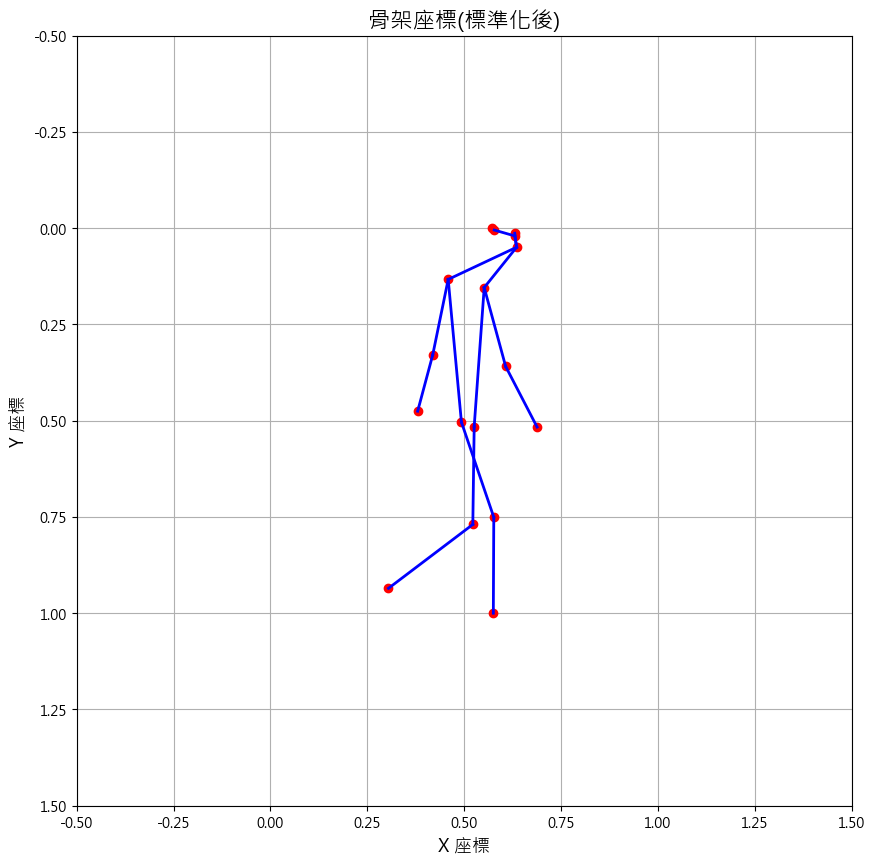

In [19]:
# 正規化後
def normalize_keypoints(keypoints, left_hip_idx=11, right_hip_idx=12):
    """
    將 keypoints 平移到髖關節中心 (0, 0)，並對 x 和 y 座標進行正規化。
    
    Args:
        keypoints (np.ndarray): 原始關節點數據，形狀為 (1, 17, 3)。
        left_hip_idx (int): 左髖關節的索引，默認為 11。
        right_hip_idx (int): 右髖關節的索引，默認為 12。
    
    Returns:
        np.ndarray: 正規化後的 keypoints。
    """
    keypoints = keypoints.astype(np.float32)  # 確保 keypoints 是浮點數型別
    keypoints = keypoints[0]  # 移除 batch 維度，取得 (17, 3)
    keypoints_xy = keypoints[:, :2]  # 提取 x, y 座標

    # 計算 y_max 和 y_min
    y_max = np.max(keypoints_xy[:, 1])
    y_min = np.min(keypoints_xy[:, 1])
    scale_factor = y_max - y_min if y_max != y_min else 1  # 避免除以零

    # 正規化 keypoints
    normalized_keypoints = np.zeros_like(keypoints_xy, dtype=np.float32)  # 明確設定為浮點型別
    normalized_keypoints[:, 0] = (keypoints_xy[:, 0] - y_min) / scale_factor
    normalized_keypoints[:, 1] = (keypoints_xy[:, 1] - y_min) / scale_factor

    # 打包回原始格式
    keypoints[:, :2] = normalized_keypoints  # 更新正規化後的座標
    return keypoints[np.newaxis, :]  # 恢復到 (1, 17, 3)

# 使用測試數據進行正規化
keypoints = normalize_keypoints(keypoints)
print("正規化後的 keypoints:")
print(keypoints)

# 測試數據，平移到原點後繪製
draw_keypoints_and_skeleton_with_axes(keypoints, inward, xlim=(-0.5, 1.5), ylim=(-0.5, 1.5),title='骨架座標(標準化後)')



正規化後的 keypoints:
[[[    0.86196    0.049412           0]
  [    0.84969    0.012941           0]
  [    0.84969        0.02           0]
  [    0.69325           0           0]
  [    0.71166   0.0047059           0]
  [    0.40184     0.13294           0]
  [    0.64417     0.15412           0]
  [    0.29755     0.32941           0]
  [    0.78834     0.35882           0]
  [    0.19632     0.47529           0]
  [          1     0.51647           0]
  [     0.4908     0.50353           0]
  [    0.57669     0.51529           0]
  [    0.70859     0.75059           0]
  [    0.56748     0.76941           0]
  [    0.70552           1           0]
  [          0     0.93529           0]]]


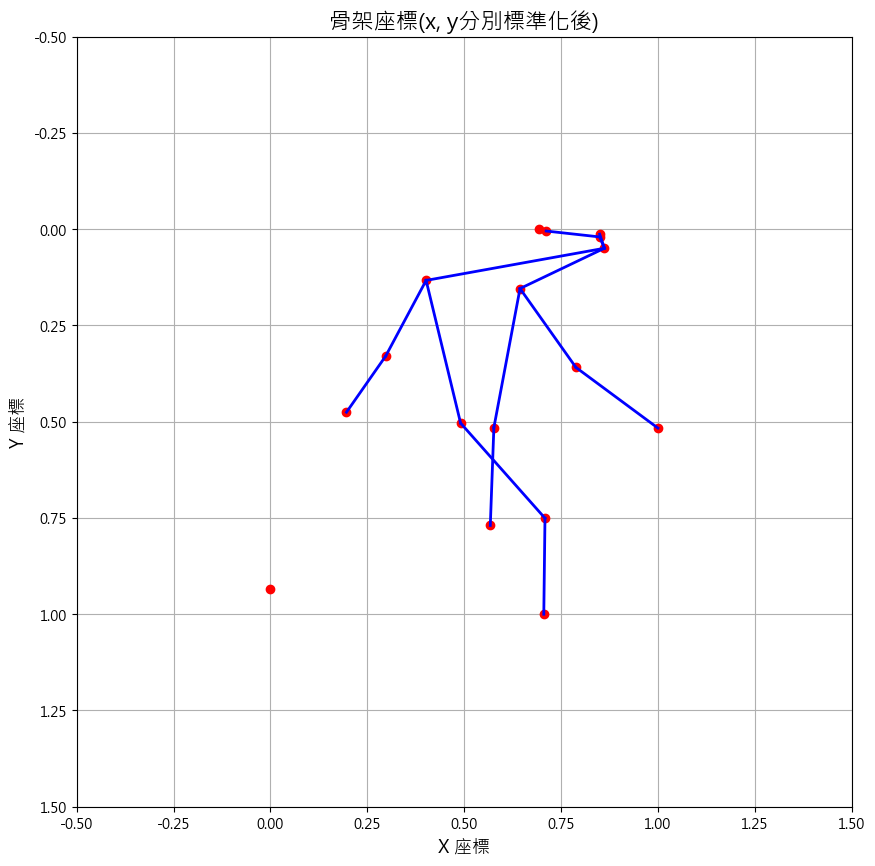

In [20]:
# 正規化後
def wrong_normalize_keypoints(keypoints, left_hip_idx=11, right_hip_idx=12):
    """
    將 keypoints 平移到髖關節中心 (0, 0)，並對 x 和 y 座標進行正規化。
    
    Args:
        keypoints (np.ndarray): 原始關節點數據，形狀為 (1, 17, 3)。
        left_hip_idx (int): 左髖關節的索引，默認為 11。
        right_hip_idx (int): 右髖關節的索引，默認為 12。
    
    Returns:
        np.ndarray: 正規化後的 keypoints。
    """
    keypoints = keypoints.astype(np.float32)  # 確保 keypoints 是浮點數型別
    keypoints = keypoints[0]  # 移除 batch 維度，取得 (17, 3)
    keypoints_xy = keypoints[:, :2]  # 提取 x, y 座標

    # 計算 y_max 和 y_min
    y_max = np.max(keypoints_xy[:, 1])
    y_min = np.min(keypoints_xy[:, 1])
    x_max = np.max(keypoints_xy[:, 0])
    x_min = np.min(keypoints_xy[:, 0])
    scale_factor_x = x_max - x_min if x_max != x_min else 1  # 避免除以零
    scale_factor_y = y_max - y_min if y_max != y_min else 1  # 避免除以零
    # 正規化 keypoints
    normalized_keypoints = np.zeros_like(keypoints_xy, dtype=np.float32)  # 明確設定為浮點型別
    normalized_keypoints[:, 0] = (keypoints_xy[:, 0] - x_min) / scale_factor_x
    normalized_keypoints[:, 1] = (keypoints_xy[:, 1] - y_min) / scale_factor_y

    # 打包回原始格式
    keypoints[:, :2] = normalized_keypoints  # 更新正規化後的座標
    return keypoints[np.newaxis, :]  # 恢復到 (1, 17, 3)

# 使用測試數據進行正規化
keypoints = wrong_normalize_keypoints(keypoints)
print("正規化後的 keypoints:")
print(keypoints)

# 測試數據，平移到原點後繪製
draw_keypoints_and_skeleton_with_axes(keypoints, inward, xlim=(-0.5, 1.5), ylim=(-0.5, 1.5), title='骨架座標(x, y分別標準化後)')